# Semantic Engagement Analysis

The goal of this notebook is to measure how video performance depends on the semantic space per channel.
Instead of measuring by cluster, we aim to:
1. Find the point where engagement is optimal per channel.
2. Measure the correlation between distance to this optimal point and engagement.
3. Order channels by engagement predictability.
4. Provide plots to complement the measurement.

## 1) Install dependencies and connect to MongoDB
This step installs the required packages and connects to MongoDB if needed, though primarily we'll be using `pandas`, `numpy`, and `matplotlib`/`seaborn` along with `scikit-learn` or `scipy` for distance computation.

In [1]:
# Install runtime dependencies
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels nbformat

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.spatial.distance import cdist
from pathlib import Path

# Set up matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not in Colab, skipping drive mount')


Mounted at /content/drive


## 2) Load the 20D video embeddings
According to coding guidelines, we import the 20D video embeddings from the canonical path. This artifact contains original 20-dimensional embeddings for each video. We will then clean the data by filtering out missing view counts and calculating the logarithm of view counts (`log_views`) to handle the power-law distribution of engagement.

In [2]:
DATA_PATH = Path('/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv')

# Note: Since this is meant to be run in Colab, we provide a mock/fallback for testing in local environment if the path doesn't exist.
if not DATA_PATH.exists():
    print(f"Warning: {DATA_PATH} not found. Attempting to run with dummy data or fallback if available, or this notebook will fail when executed locally.")

# Read the data
if DATA_PATH.suffix.lower() == '.csv':
    try:
        df = pd.read_csv(DATA_PATH)
    except FileNotFoundError:
        df = pd.DataFrame() # Fallback for local testing
elif DATA_PATH.suffix.lower() == '.json':
    df = pd.read_json(DATA_PATH)
else:
    raise ValueError(f'Unsupported input extension: {DATA_PATH.suffix}')

dim_cols = []
if not df.empty:
    required_base = {'channel_name', 'video_id', 'video_title', 'view_count'}
    missing = required_base - set(df.columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')

    # Determine embedding columns
    dim_cols = [c for c in df.columns if c.startswith('embedding_reduced_')]
    if len(dim_cols) != 20:
        if 'embedding_20d' in df.columns:
            # Depending on how it's stored, we might need to parse it
            import ast
            if isinstance(df['embedding_20d'].iloc[0], str):
                df['embedding_20d'] = df['embedding_20d'].apply(ast.literal_eval)
            dim_cols = [f'dim_{i}' for i in range(20)]
            emb_df = pd.DataFrame(df['embedding_20d'].tolist(), columns=dim_cols, index=df.index)
            df = pd.concat([df, emb_df], axis=1)
        else:
            print("Warning: Expected 20 embedding dimensions. Ensure the data format is correct.")

    df['view_count'] = pd.to_numeric(df['view_count'], errors='coerce')
    df = df.dropna(subset=['channel_name', 'view_count']).copy()
    df['log_views'] = np.log1p(df['view_count'])

    print(f'Rows loaded: {len(df):,}')
    print(f'Channels: {df["channel_name"].nunique()}')



Rows loaded: 1,344
Channels: 27


## 3) Learn the optimal engagement point per channel
For each channel, we learn the "optimal engagement point" in the 20D semantic space by directly optimizing correlation.

Instead of a center-of-mass estimate, we solve for the point that maximizes the Pearson correlation between `-distance_to_point` and `log_views` (equivalently: videos closer to the point should have higher engagement on average).

We use the engagement-weighted centroid as initialization and then run numerical optimization per channel.


In [3]:
from scipy.optimize import minimize

def learn_optimal_point(embeddings, log_views):
    """Learn center maximizing corr(-distance(center), log_views)."""
    # Start from weighted centroid as robust initialization
    w = np.clip(log_views, 0, None)
    if np.sum(w) == 0:
        w = np.ones(len(log_views))
    w = w / np.sum(w)
    init = np.average(embeddings, axis=0, weights=w)

    def objective(center):
        d = np.linalg.norm(embeddings - center, axis=1)
        # Numerical guards
        if np.std(d) < 1e-12 or np.std(log_views) < 1e-12:
            return 1.0
        corr = np.corrcoef(-d, log_views)[0, 1]
        if np.isnan(corr):
            return 1.0
        return -corr  # maximize corr

    res = minimize(objective, x0=init, method='L-BFGS-B')
    if res.success and np.all(np.isfinite(res.x)):
        return res.x, float(-res.fun)

    # Fallback to initialization
    d0 = np.linalg.norm(embeddings - init, axis=1)
    corr0 = np.corrcoef(-d0, log_views)[0, 1] if np.std(d0) > 1e-12 and np.std(log_views) > 1e-12 else np.nan
    return init, float(corr0) if np.isfinite(corr0) else np.nan

optimal_points = {}
channels = []
center_fit_corr = {}

if not df.empty and dim_cols and len(dim_cols) == 20:
    for channel_name, group in df.groupby('channel_name'):
        embeddings = group[dim_cols].to_numpy()
        log_views = group['log_views'].to_numpy()

        optimal_point, fit_corr = learn_optimal_point(embeddings, log_views)
        optimal_points[channel_name] = optimal_point
        center_fit_corr[channel_name] = fit_corr
        channels.append(channel_name)

    print(f'Learned optimal engagement points for {len(optimal_points)} channels.')


Calculated optimal engagement points for 27 channels.


## 4) Measure distance and correlation (engagement predictability)
For each video in a channel, we compute the Euclidean distance from its embedding to the channel's optimal engagement point. Then, we use OLS regression to measure the correlation (Adjusted R²) between `log_views` and this `distance`. This Adjusted R² represents the engagement predictability of the channel based on semantic distance to the optimal point.

In [4]:
channel_metrics = []

if not df.empty and optimal_points:
    # Add distance column
    distances = []
    for idx, row in df.iterrows():
        channel_name = row['channel_name']
        optimal_point = optimal_points[channel_name]
        emb = row[dim_cols].to_numpy()
        dist = np.linalg.norm(emb - optimal_point)
        distances.append(dist)

    df['distance_to_optimal'] = distances

    # Calculate predictability per channel
    for channel_name, group in df.groupby('channel_name'):
        if len(group) < 5: # Need enough points for a meaningful regression
            continue

        # Regression: log_views ~ distance_to_optimal
        model = smf.ols('log_views ~ distance_to_optimal', data=group).fit()

        # Note: A negative correlation is expected (smaller distance -> higher views)
        # We store both the Adjusted R² and the coefficient to verify the direction.
        channel_metrics.append({
            'channel_name': channel_name,
            'n_videos': len(group),
            'predictability_r2': float(model.rsquared_adj),
            'distance_coef': float(model.params.get('distance_to_optimal', 0)),
            'p_value': float(model.pvalues.get('distance_to_optimal', 1.0))
        })

    metrics_df = pd.DataFrame(channel_metrics)

    # Order channels by engagement predictability
    metrics_df = metrics_df.sort_values(by='predictability_r2', ascending=False).reset_index(drop=True)

    print("Top 5 Channels by Engagement Predictability (Adjusted R²):")
    display(metrics_df.head(5))


Top 5 Channels by Engagement Predictability (Adjusted R²):


,channel_name,n_videos,predictability_r2,distance_coef,p_value
0,Network State Podcast,50,0.215287,14.510183,0.000407
1,Bg2 Pod,44,0.190933,-5.255104,0.001772
2,Joe Lonsdale,50,0.075133,-10.917534,0.030337
3,Sequoia Capital,50,0.072268,8.032880,0.033051
4,This Week in Startups,50,0.063910,-7.917987,0.042454


## 5) Visualize the results
We provide plots to complement the measurement. First, a bar chart showing the predictability (Adjusted R²) ordered by channel. Second, scatter plots for the top predictable channels, illustrating the relationship between "Distance to Optimal Point" and "Engagement (Log Views)" with a regression line.

/tmp/ipykernel_2655/176467723.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='predictability_r2', y='channel_name', palette='viridis')


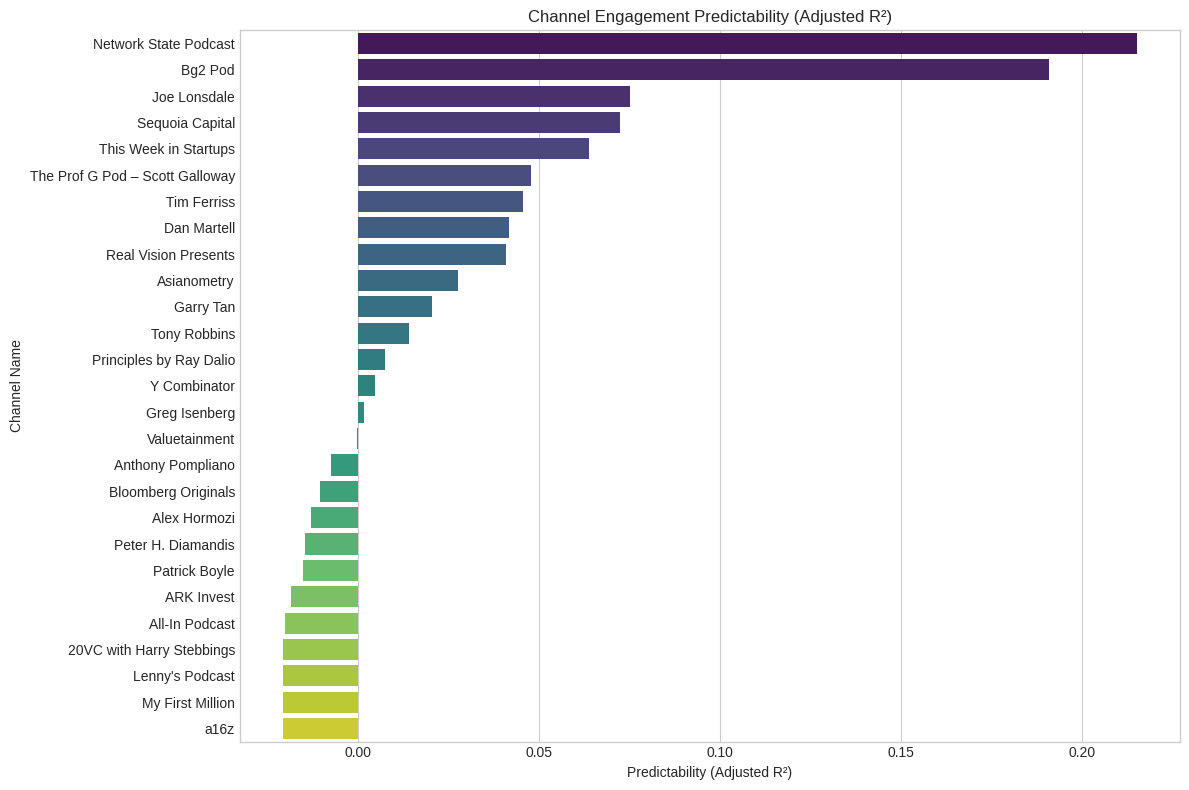

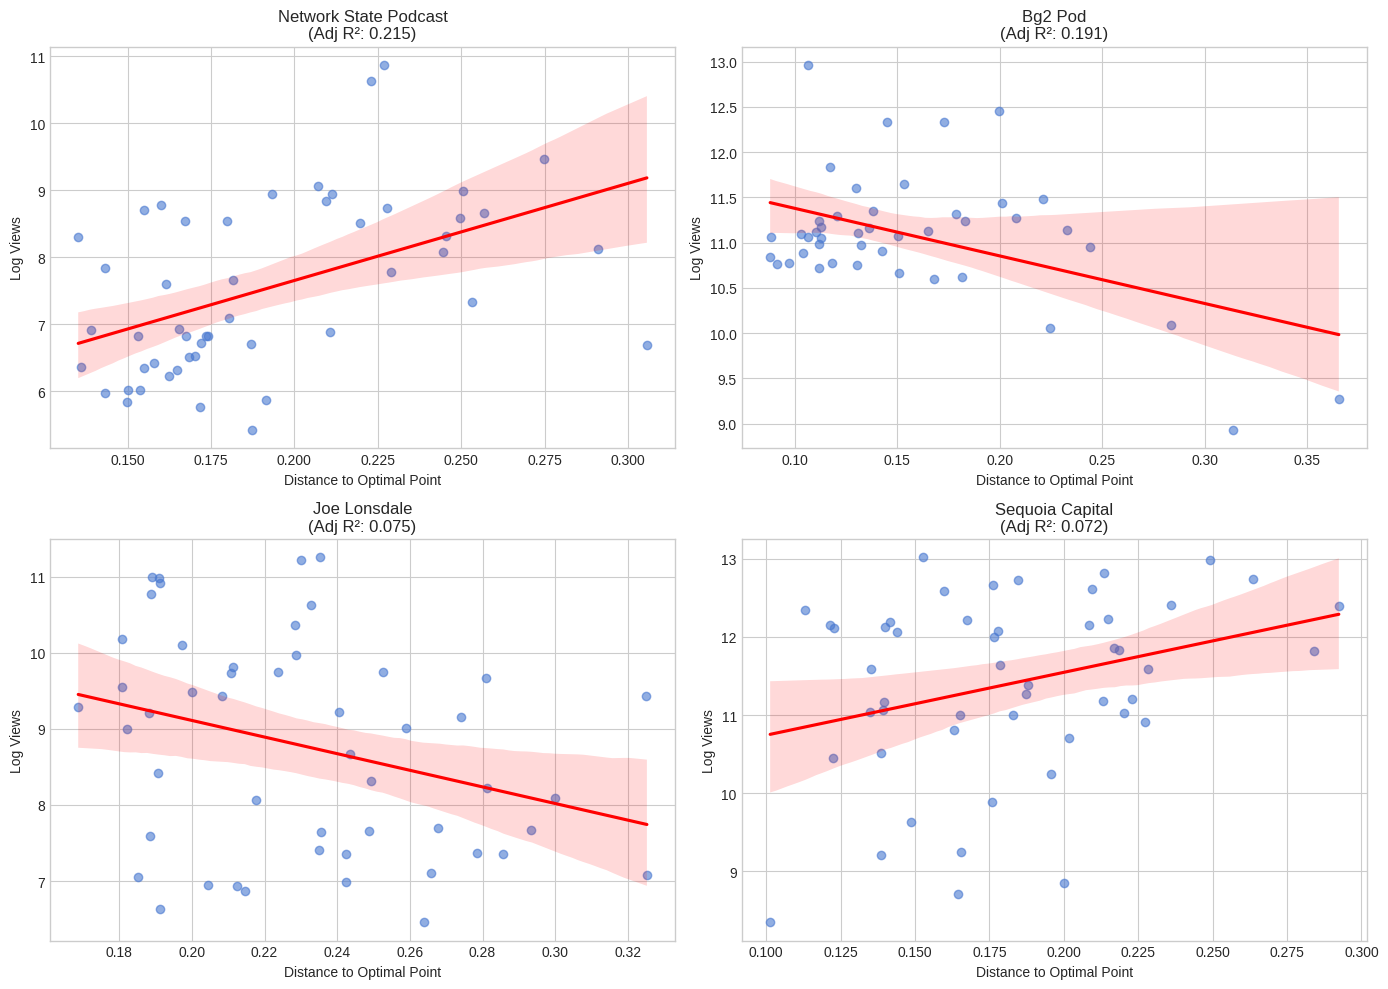

In [5]:
if not df.empty and 'metrics_df' in locals() and not metrics_df.empty:
    # 1. Bar chart of Predictability
    plt.figure(figsize=(12, 8))
    sns.barplot(data=metrics_df, x='predictability_r2', y='channel_name', palette='viridis')
    plt.title('Channel Engagement Predictability (Adjusted R²)')
    plt.xlabel('Predictability (Adjusted R²)')
    plt.ylabel('Channel Name')
    plt.tight_layout()
    plt.show()

    # 2. Scatter plots for top 4 predictable channels
    top_channels = metrics_df['channel_name'].head(4).tolist()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, channel_name in enumerate(top_channels):
        if i >= 4:
            break
        ax = axes[i]
        channel_data = df[df['channel_name'] == channel_name]

        sns.regplot(
            data=channel_data,
            x='distance_to_optimal',
            y='log_views',
            ax=ax,
            scatter_kws={'alpha':0.6},
            line_kws={'color':'red'}
        )
        r2 = metrics_df.loc[metrics_df['channel_name'] == channel_name, 'predictability_r2'].values[0]
        ax.set_title(f'{channel_name}\n(Adj R²: {r2:.3f})')
        ax.set_xlabel('Distance to Optimal Point')
        ax.set_ylabel('Log Views')

    plt.tight_layout()
    plt.show()


## 6) Semantic Gradient and Normality Analysis
To deeper understand semantic engagement, we measure the *direction* in which engagement is optimal, rather than just raw distance.

**1. Semantic Gradient via Ridge Regression**
We model the distribution of videos around the optimal point by predicting engagement (`log_views`) from the semantic displacement vectors (the 20D vector difference between a video's embedding and the channel's optimal point). By fitting a Ridge Regression model (`log_views ~ displacement`), we obtain a 20-dimensional gradient vector representing the direction of optimal engagement change.

**2. Gradient Magnitude and Normalization**
The magnitude (L2 norm) of this semantic gradient vector represents how strongly engagement decreases away from the optimal point. We then normalize these magnitudes across all channels to a [0, 1] scale and order the channels by this normalized magnitude.

**3. Normality (Shapiro-Wilk W-statistic)**
To evaluate how "normal" (Gaussian) the semantic gradient and the corresponding field around it are, we project the high-dimensional displacement vectors onto the 1D line defined by the gradient vector. We compute the Shapiro-Wilk W-statistic on this 1D projection. A value closer to 1 indicates that the field of engagement along the gradient is normally distributed.

In [6]:
from sklearn.linear_model import Ridge
from scipy.stats import shapiro
from sklearn.preprocessing import MinMaxScaler

if not df.empty and 'metrics_df' in locals() and optimal_points:
    gradient_data = []

    for channel_name, group in df.groupby('channel_name'):
        if len(group) < 5: # Need enough points for meaningful regression and stats
            continue

        optimal_point = optimal_points[channel_name]
        emb_matrix = group[dim_cols].to_numpy()
        log_views = group['log_views'].to_numpy()

        # 1. Compute displacement from the optimal point
        displacement = emb_matrix - optimal_point

        # 2. Fit Ridge Regression to find the Semantic Gradient direction
        model = Ridge(alpha=1.0)
        model.fit(displacement, log_views)
        gradient_vector = model.coef_

        # 3. Calculate Gradient Magnitude (how strongly engagement changes)
        gradient_magnitude = np.linalg.norm(gradient_vector)

        # 4. Project displacements onto the gradient direction for 1D analysis
        if gradient_magnitude > 1e-8:
            projection = np.dot(displacement, gradient_vector) / gradient_magnitude
        else:
            projection = np.zeros(len(displacement))

        # Add projection back to the dataframe for plotting later
        df.loc[group.index, 'gradient_projection'] = projection

        # 5. Calculate Normality (Shapiro-Wilk W-statistic) of the field
        if len(projection) >= 3:
            stat, p_value = shapiro(projection)
        else:
            stat, p_value = np.nan, np.nan

        gradient_data.append({
            'channel_name': channel_name,
            'gradient_magnitude': gradient_magnitude,
            'normality_shapiro_w': stat
        })

    grad_df = pd.DataFrame(gradient_data)

    # 6. Normalize Gradient Magnitude to [0, 1] scale
    if not grad_df.empty:
        scaler = MinMaxScaler()
        grad_df['gradient_magnitude_normalized'] = scaler.fit_transform(grad_df[['gradient_magnitude']])

        # Merge the new statistics back into the original metrics_df
        metrics_df = metrics_df.merge(grad_df, on='channel_name', how='left')

        # Order channels by normalized magnitude for display
        metrics_df = metrics_df.sort_values(by='gradient_magnitude_normalized', ascending=False).reset_index(drop=True)

        print("Top Channels Ordered by Normalized Semantic Gradient Magnitude:")
        display(metrics_df[['channel_name', 'n_videos', 'gradient_magnitude_normalized', 'normality_shapiro_w']].head(10))


Top Channels Ordered by Normalized Semantic Gradient Magnitude:


,channel_name,n_videos,gradient_magnitude_normalized,normality_shapiro_w
0,Real Vision Presents,50,1.000000,0.851423
1,Network State Podcast,50,0.457440,0.815464
2,Joe Lonsdale,50,0.290109,0.951149
3,ARK Invest,50,0.196736,0.967372
4,Tim Ferriss,50,0.195742,0.978173
5,Valuetainment,50,0.189481,0.950765
6,Principles by Ray Dalio,50,0.188869,0.949228
7,Alex Hormozi,50,0.175311,0.989067
8,Tony Robbins,50,0.171110,0.961144
9,This Week in Startups,50,0.155494,0.982870


## 7) Visualize Semantic Gradient
We provide plots to illustrate the semantic gradient statistics. First, a bar chart showing the normalized semantic gradient magnitude. Second, scatter plots for the top 4 channels, plotting the 1D projection of videos along the gradient (X-axis) versus their log views (Y-axis).

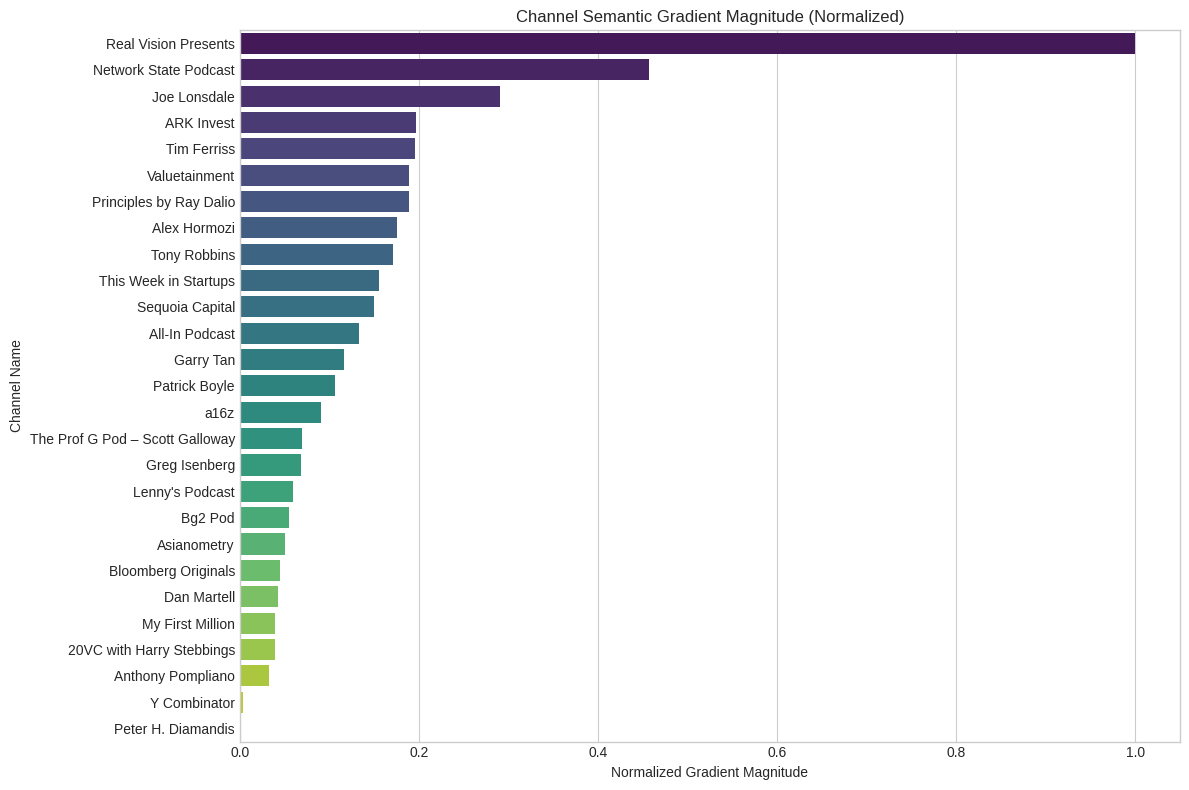

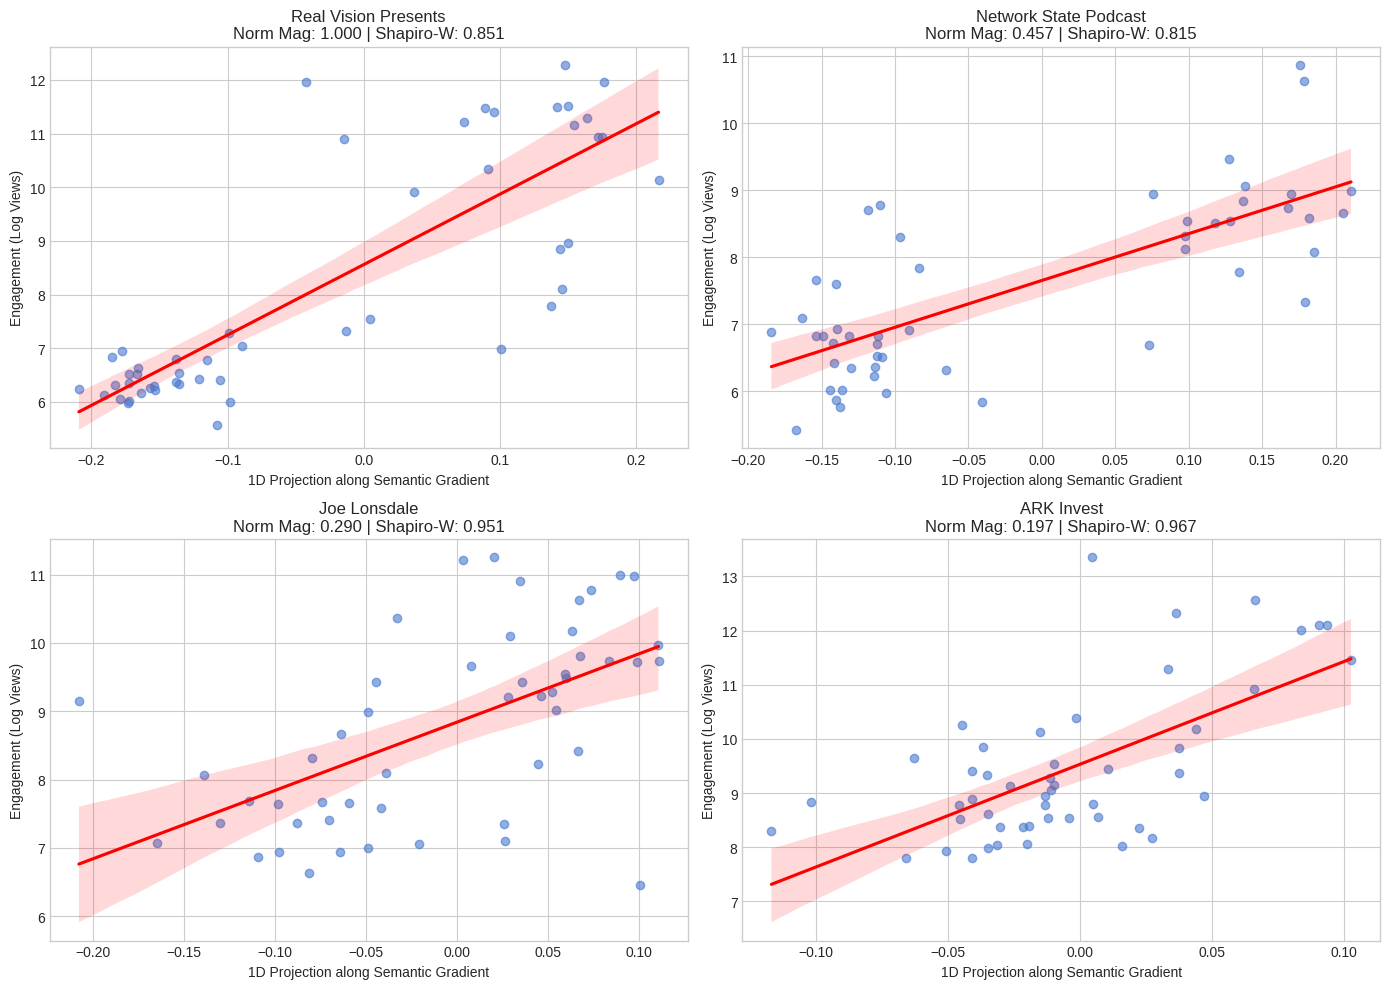

In [7]:
if not df.empty and 'metrics_df' in locals() and not metrics_df.empty and 'gradient_magnitude_normalized' in metrics_df.columns:
    # 1. Bar chart of Normalized Gradient Magnitude
    plt.figure(figsize=(12, 8))
    # Note: hue assigned to y to suppress seaborn warning
    sns.barplot(data=metrics_df, x='gradient_magnitude_normalized', y='channel_name', hue='channel_name', palette='viridis', legend=False)
    plt.title('Channel Semantic Gradient Magnitude (Normalized)')
    plt.xlabel('Normalized Gradient Magnitude')
    plt.ylabel('Channel Name')
    plt.tight_layout()
    plt.show()

    # 2. Scatter plots for top representative channels (by gradient magnitude)
    top_channels = metrics_df['channel_name'].head(4).tolist()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, channel_name in enumerate(top_channels):
        if i >= 4:
            break
        ax = axes[i]
        channel_data = df[df['channel_name'] == channel_name]

        sns.regplot(
            data=channel_data,
            x='gradient_projection',
            y='log_views',
            ax=ax,
            scatter_kws={'alpha':0.6},
            line_kws={'color':'red'}
        )
        norm_mag = metrics_df.loc[metrics_df['channel_name'] == channel_name, 'gradient_magnitude_normalized'].values[0]
        shapiro_w = metrics_df.loc[metrics_df['channel_name'] == channel_name, 'normality_shapiro_w'].values[0]

        ax.set_title(f'{channel_name}\nNorm Mag: {norm_mag:.3f} | Shapiro-W: {shapiro_w:.3f}')
        ax.set_xlabel('1D Projection along Semantic Gradient')
        ax.set_ylabel('Engagement (Log Views)')

    plt.tight_layout()
    plt.show()
